In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
df = pd.read_csv('/content/car_insurance.csv', engine='python')

In [51]:
df.head()

,PolicyID,ClaimNb,Exposure,Power,CarAge,DriverAge,Brand,Gas,Region,Density
0,1,0,0.09,g,0,46,Japanese (except Nissan) or Korean,Diesel,Aquitaine,76
1,2,0,0.84,g,0,46,Japanese (except Nissan) or Korean,Diesel,Aquitaine,76
2,3,0,0.52,f,2,38,Japanese (except Nissan) or Korean,Regular,Nord-Pas-de-Calais,3003
3,4,0,0.45,f,2,38,Japanese (except Nissan) or Korean,Regular,Nord-Pas-de-Calais,3003
4,5,0,0.15,g,0,41,Japanese (except Nissan) or Korean,Diesel,Pays-de-la-Loire,60


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44690 entries, 0 to 44689
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   PolicyID   44690 non-null  int64  
 1   ClaimNb    44690 non-null  int64  
 2   Exposure   44690 non-null  float64
 3   Power      44690 non-null  object 
 4   CarAge     44690 non-null  int64  
 5   DriverAge  44690 non-null  int64  
 6   Brand      44690 non-null  object 
 7   Gas        44690 non-null  object 
 8   Region     44690 non-null  object 
 9   Density    44690 non-null  int64  
dtypes: float64(1), int64(5), object(4)
memory usage: 3.4+ MB


In [53]:
df.isnull().sum()

,0
PolicyID,0
ClaimNb,0
Exposure,0
Power,0
CarAge,0
DriverAge,0
Brand,0
Gas,0
Region,0
Density,0


In [54]:
df.describe()

,PolicyID,ClaimNb,Exposure,CarAge,DriverAge,Density
count,44690.000000,44690.000000,44690.000000,44690.000000,44690.000000,44690.000000
mean,22345.500000,0.050571,0.604648,7.784493,44.547013,1395.810271
std,12901.036102,0.229399,0.368629,5.745526,14.930876,4031.273478
min,1.000000,0.000000,0.002732,0.000000,18.000000,2.000000
25%,11173.250000,0.000000,0.240000,3.000000,33.000000,56.000000
50%,22345.500000,0.000000,0.650000,7.000000,43.000000,194.000000
75%,33517.750000,0.000000,1.000000,12.000000,54.000000,983.000000
max,44690.000000,4.000000,1.000000,100.000000,99.000000,27000.000000


In [55]:
df.shape

(44690, 10)

In [56]:
df['DriverAge_Group'] = pd.cut(df['DriverAge'], bins=[18, 25, 35, 45, 55, 65, 99], labels=['18-24', '25-34', '35-44', '45-54', '55-64', '65+'])
df['CarAge_Group'] = pd.cut(df['CarAge'], bins=[-1, 0, 5, 10, 15, df['CarAge'].max()], labels=['New', '0-5', '6-10', '11-15', '16+'])
df['Log_Exposure'] = np.log1p(df['Exposure'])
df['Is_Claim_Made'] = (df['ClaimNb'] > 0).astype(int)
df['Density_Category'] = pd.qcut(df['Density'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])

In [57]:
df.head()

,PolicyID,ClaimNb,Exposure,Power,CarAge,DriverAge,Brand,Gas,Region,Density,DriverAge_Group,CarAge_Group,Log_Exposure,Is_Claim_Made,Density_Category
0,1,0,0.09,g,0,46,Japanese (except Nissan) or Korean,Diesel,Aquitaine,76,45-54,New,0.086178,0,Medium
1,2,0,0.84,g,0,46,Japanese (except Nissan) or Korean,Diesel,Aquitaine,76,45-54,New,0.609766,0,Medium
2,3,0,0.52,f,2,38,Japanese (except Nissan) or Korean,Regular,Nord-Pas-de-Calais,3003,35-44,0-5,0.418710,0,Very High
3,4,0,0.45,f,2,38,Japanese (except Nissan) or Korean,Regular,Nord-Pas-de-Calais,3003,35-44,0-5,0.371564,0,Very High
4,5,0,0.15,g,0,41,Japanese (except Nissan) or Korean,Diesel,Pays-de-la-Loire,60,35-44,New,0.139762,0,Medium


In [58]:
df.isnull().sum()

,0
PolicyID,0
ClaimNb,0
Exposure,0
Power,0
CarAge,0
DriverAge,0
Brand,0
Gas,0
Region,0
Density,0


In [59]:
df['DriverAge_Group'] = df['DriverAge_Group'].fillna(df['DriverAge_Group'].mode()[0])

In [73]:
df.head(33)

,PolicyID,ClaimNb,Exposure,Power,CarAge,DriverAge,Brand,Gas,Region,Density,DriverAge_Group,CarAge_Group,Log_Exposure,Is_Claim_Made,Density_Category
0,1,0,0.09,g,0,46,Japanese (except Nissan) or Korean,Diesel,Aquitaine,76,45-54,New,0.086178,0,Medium
1,2,0,0.84,g,0,46,Japanese (except Nissan) or Korean,Diesel,Aquitaine,76,45-54,New,0.609766,0,Medium
2,3,0,0.52,f,2,38,Japanese (except Nissan) or Korean,Regular,Nord-Pas-de-Calais,3003,35-44,0-5,0.418710,0,Very High
3,4,0,0.45,f,2,38,Japanese (except Nissan) or Korean,Regular,Nord-Pas-de-Calais,3003,35-44,0-5,0.371564,0,Very High
4,5,0,0.15,g,0,41,Japanese (except Nissan) or Korean,Diesel,Pays-de-la-Loire,60,35-44,New,0.139762,0,Medium
5,6,0,0.75,g,0,41,Japanese (except Nissan) or Korean,Diesel,Pays-de-la-Loire,60,35-44,New,0.559616,0,Medium
6,7,0,0.81,d,1,27,Japanese (except Nissan) or Korean,Regular,Aquitaine,695,25-34,0-5,0.593327,0,High
7,8,0,0.05,d,0,27,Japanese (except Nissan) or Korean,Regular,Aquitaine,695,25-34,New,0.048790,0,High
8,9,0,0.76,d,9,23,Fiat,Regular,Nord-Pas-de-Calais,7887,18-24,6-10,0.565314,0,Very High
9,10,0,0.34,i,0,44,Japanese (except Nissan) or Korean,Regular,Ile-de-France,27000,35-44,New,0.292670,0,Very High


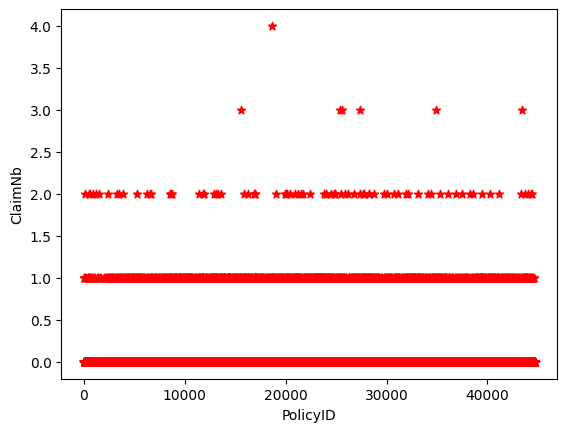

In [61]:
plt.xlabel('PolicyID')
plt.ylabel('ClaimNb')
plt.scatter(df['PolicyID'],df['ClaimNb'],color='red',marker='*')

In [62]:
X = df.drop(columns=['ClaimNb'])
y = df['ClaimNb']
X = pd.get_dummies(X, columns=['Power', 'Brand', 'Gas', 'Region', 'CarAge_Group', 'Density_Category'], drop_first=True)

In [63]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [64]:
problematic_column = 'DriverAge_Group'
X_train = pd.get_dummies(X_train, columns=[problematic_column], drop_first=True)
X_test = pd.get_dummies(X_test, columns=[problematic_column], drop_first=True)

train_cols = X_train.columns
test_cols = X_test.columns

missing_in_test = set(train_cols) - set(test_cols)
for c in missing_in_test:
    X_test[c] = 0

missing_in_train = set(test_cols) - set(train_cols)
for c in missing_in_train:
    X_train[c] = 0
X_test = X_test[train_cols]

In [65]:
model = Ridge(alpha=50, max_iter=100,tol=0.1, random_state=42)
model.fit(X_train, y_train)

Ridge(alpha=50, max_iter=100, random_state=42, tol=0.1)

In [66]:
model.score(X_test, y_test)

0.9587748703812642

In [67]:
model.score(X_train, y_train)

0.9509954096654365

In [68]:
import joblib
joblib.dump(model,'model5.joblib')

['model5.joblib']

In [69]:
model=joblib.load('model5.joblib')